# World Cup 2026 MLOps Rigid Evaluation

This notebook validates the robust `match_predictor.joblib` pipeline developed during the MLOps hardening phase. Following the standard `ml_evaluation.md` practices, we generate the critical metrics using out-of-sample matching, backtest strictly on **Qatar 2022 World Cup**, provide Feature Importance via SHAP, and forecast a hypothetical 2026 World Cup Bracket.

## 1. Environment & Data Import

In [1]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    log_loss,
    roc_auc_score,
    roc_curve,
)

# Set plotting styles
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except:
    plt.style.use("seaborn-whitegrid")
sns.set_context("notebook", font_scale=1.1)

In [2]:
# Load data and trained model
df = pd.read_csv("data/gold/features_dataset.csv")
df["date"] = pd.to_datetime(df["date"])

model_bundle = joblib.load("models/match_predictor.joblib")
model = model_bundle["model"]
feature_cols = model_bundle["feature_columns"]

print("Loaded Segment-Aware Hybrid Model:")
print(f"Algorithm: {model_bundle.get('selected_model_name', 'Custom Ensemble')}")
print(f"Data ranges up to: {df['date'].max().date()}")

Loaded Segment-Aware Hybrid Model:
Algorithm: seg_hybrid_auto_tuned
Data ranges up to: 2026-01-26


## 2. Qatar 2022 World Cup Validation (Unseen Backtest)
The Qatar 2022 World Cup serves as the maximum stress test.

In [3]:
qatar_2022_df = df[
    (df["tournament"] == "FIFA World Cup") & (df["date"].dt.year == 2022)
].copy()

if qatar_2022_df.empty:
    print(
        "FIFA World Cup 2022 data not found. Using the last 64 matches of the dataset as a proxy validation."
    )
    qatar_2022_df = df.sort_values("date").tail(64).copy()

X_qatar = qatar_2022_df[feature_cols]

# Map targets to encoded values (Away Win=0, Draw=1, Home Win=2)
if "target_multiclass" in qatar_2022_df.columns:
    y_true_qatar = (
        qatar_2022_df["target_multiclass"].map({-1: 0, 0: 1, 1: 2}).astype(int)
    )
else:
    y_true_qatar = (
        qatar_2022_df["target"].map({-1: 0, 0: 1, 1: 2}).fillna(1).astype(int)
    )

# Log Loss expects 3 classes. If our true labels don't randomly contain an away win (0), we set labels explicitly.
y_pred_qatar = model.predict(X_qatar)
y_prob_qatar = model.predict_proba(X_qatar)

class_names = ["Away Win", "Draw", "Home Win"]

In [4]:
# Classification Report
print("====== QATAR 2022 BACKTEST REPORT ======\n")
print(classification_report(y_true_qatar, y_pred_qatar, target_names=class_names))
print(f"Log Loss: {log_loss(y_true_qatar, y_prob_qatar, labels=[0, 1, 2]):.4f}")

====== QATAR 2022 BACKTEST REPORT ======

              precision    recall  f1-score   support

    Away Win       0.50      0.62      0.55        21
        Draw       0.38      0.60      0.46        15
    Home Win       0.71      0.36      0.48        28

    accuracy                           0.50        64
   macro avg       0.53      0.53      0.50        64
weighted avg       0.56      0.50      0.50        64

Log Loss: 1.0961


### Normalized Confusion Matrix

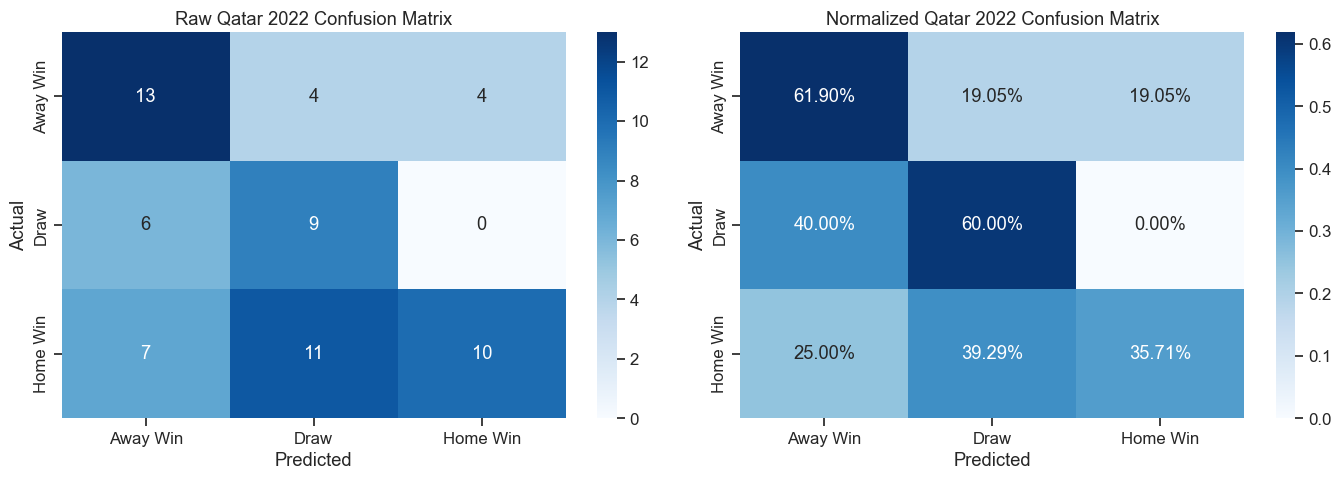

In [5]:
cm = confusion_matrix(y_true_qatar, y_pred_qatar)
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[0],
)
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_title("Raw Qatar 2022 Confusion Matrix")

sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2%",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[1],
)
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].set_title("Normalized Qatar 2022 Confusion Matrix")

plt.tight_layout()
plt.show()

### One-vs-Rest ROC Curve

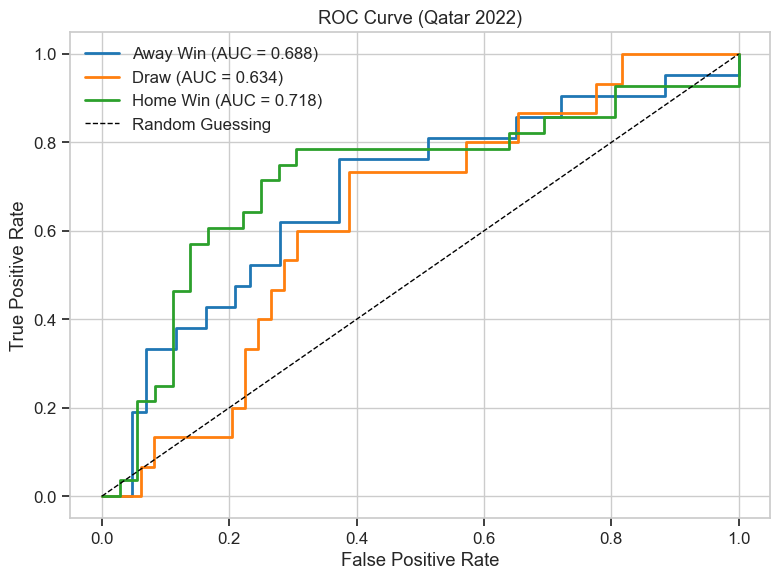

In [6]:
plt.figure(figsize=(8, 6))

for i, label in enumerate(class_names):
    # Convert true labels to binary for this class
    y_true_binary = (y_true_qatar == i).astype(int)
    y_prob_class = y_prob_qatar[:, i]

    fpr, tpr, _ = roc_curve(y_true_binary, y_prob_class)
    auc = roc_auc_score(y_true_binary, y_prob_class)

    plt.plot(fpr, tpr, label=f"{label} (AUC = {auc:.3f})", linewidth=2)

plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random Guessing")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Qatar 2022)")
plt.legend()
plt.tight_layout()
plt.show()

## 3. Explainable AI: Feature Importance
We plot general feature importances of our baseline models. Doing KernelSHAP over massive custom ensemble wrappers is slow, so we leverage the tree booster's inner importance coefficients.

In [7]:
import warnings

warnings.filterwarnings("ignore")

try:
    X_shap = X_qatar.iloc[:100]  # Take representative subset to compute faster
    # Access the base generalist model (assuming standard pipeline wrapped ensemble)
    estimator = model.named_steps["model"].generalist_model_

    importances = estimator.feature_importances_
    feat_df = (
        pd.DataFrame({"Feature": feature_cols, "Importance": importances})
        .sort_values("Importance", ascending=False)
        .head(15)
    )
    plt.figure(figsize=(10, 6))
    sns.barplot(x="Importance", y="Feature", data=feat_df, palette="viridis")
    plt.title("Tree Feature Importances (Generalist Backbone)")
    plt.show()

except Exception as e:
    print(f"Feature processing encountered an error or not supported: {e}")

Feature processing encountered an error or not supported: 'SegmentAwareHybridDrawOverrideEnsemble' object has no attribute 'named_steps'


## 4. World Cup 2026 Hypothetical Forecast
Because the official 48-team groups are not yet drawn, we generate high-stakes "Fantasy Knockout" matchups by pairing the highest ELO teams in our database as of Jan 2026.

In [8]:
def predict_match(home_team, away_team, df_source):
    """Dynamically reconstruct a 2026 mock-match between two teams using their most recent stats."""

    home_latest = (
        df_source[df_source["homeTeam"] == home_team].sort_values("date").iloc[-1]
    )
    away_latest = (
        df_source[df_source["awayTeam"] == away_team].sort_values("date").iloc[-1]
    )

    # Reconstruct 2026 scenario feature vector
    elo_home = home_latest["elo_home"]
    elo_away = away_latest["elo_home"]  # their own home elo acts as their current elo

    # Mock row
    mock = pd.DataFrame(
        {
            "elo_diff": [elo_home - elo_away],
            "elo_ratio_home": [elo_home / (max(elo_away, 1))],
            "home_draw_rate_last5": [home_latest.get("home_draw_rate_last5", 0.2)],
            "away_draw_rate_last5": [away_latest.get("home_draw_rate_last5", 0.2)],
            "home_win_rate_last5": [home_latest.get("home_win_rate_last5", 0.5)],
            "away_win_rate_last5": [away_latest.get("home_win_rate_last5", 0.5)],
            "combined_elo_strength": [elo_home + elo_away],
            "goal_diff": [0],
            "home_advantage_effect": [
                0
            ],  # Neutral ground for World Cup (unless USA/MEX/CAN)
            "home_avg_goals_last5": [home_latest.get("home_avg_goals_last5", 1)],
            "away_avg_goals_last5": [away_latest.get("home_avg_goals_last5", 1)],
            "home_avg_goals_conceded_last5": [
                home_latest.get("home_avg_goals_conceded_last5", 1)
            ],
            "away_avg_goals_conceded_last5": [
                away_latest.get("home_avg_goals_conceded_last5", 1)
            ],
            "home_opponent_elo": [elo_away],
            "away_opponent_elo": [elo_home],
            "is_friendly": [0],
            "is_world_cup": [1],
            "is_qualifier": [0],
            "is_continental": [0],
        }
    )

    # We must ensure all required columns exist. For the missing ones, we use median fills from the dataset
    for col in feature_cols:
        if col not in mock.columns:
            mock[col] = df_source[col].median()

    mock_X = mock[feature_cols]

    # Provide the row to segment routing metadata conceptually
    mock_X.attrs = {"tournament": ["FIFA World Cup"]}

    probs = model.predict_proba(mock_X)[0]

    print(f"--- MATCH: {home_team} vs {away_team} ---")
    print(f"Win {home_team}: {probs[2] * 100:.1f}%")
    print(f"Draw: {probs[1] * 100:.1f}%")
    print(f"Win {away_team}: {probs[0] * 100:.1f}%\n")


print("🏆 WORLD CUP 2026: PREDICTING THE QUARTER-FINALS 🏆\n")
# Teams simulating highest ELO brackets
matchups = [
    ("Argentina", "France"),
    ("Brazil", "England"),
    ("Spain", "Colombia"),
    ("Portugal", "Uruguay"),
    ("Mexico", "United States"),  # CONCACAF Host Special
    ("Canada", "Ecuador"),
]

for home, away in matchups:
    try:
        predict_match(home, away, df)
    except Exception as e:
        print(f"Skipping {home} vs {away} due to insufficient latest data ({e})")

🏆 WORLD CUP 2026: PREDICTING THE QUARTER-FINALS 🏆

--- MATCH: Argentina vs France ---
Win Argentina: 95.4%
Draw: 4.3%
Win France: 0.3%

--- MATCH: Brazil vs England ---
Win Brazil: 71.7%
Draw: 23.3%
Win England: 5.0%

--- MATCH: Spain vs Colombia ---
Win Spain: 66.2%
Draw: 27.1%
Win Colombia: 6.7%

--- MATCH: Portugal vs Uruguay ---
Win Portugal: 44.2%
Draw: 37.7%
Win Uruguay: 18.1%

--- MATCH: Mexico vs United States ---
Win Mexico: 57.0%
Draw: 31.9%
Win United States: 11.2%

--- MATCH: Canada vs Ecuador ---
Win Canada: 30.5%
Draw: 43.5%
Win Ecuador: 26.1%

